# Bivariate Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/processed/final_dataset_clean.csv')

## Gender vs Weight-for_Age Z-Score

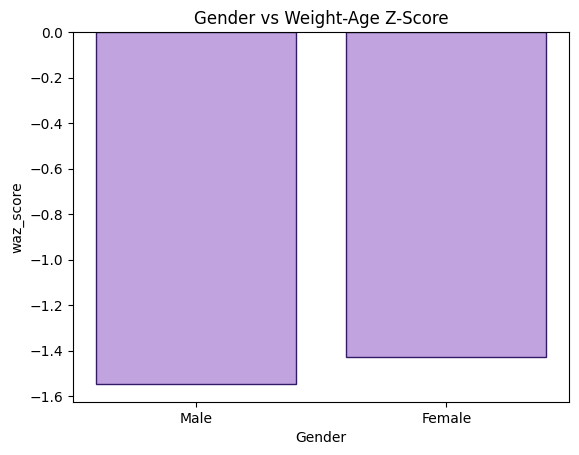

In [2]:
means = df.groupby('child_sex')['waz_score'].mean()

color = (0.6, # redness
         0.4, # greenness
         0.8, # blueness
         0.6  # transparency
         )

edge_color = (0.2, # redness
              0.1, # greenness
              0.4, # blueness
              1  # transparency
              )

plt.bar(means.index, means.values, color=color, edgecolor=edge_color)
plt.title('Gender vs Weight-Age Z-Score')
plt.xticks(means.index, ['Male', 'Female'])
plt.xlabel("Gender")
plt.ylabel("waz_score")
# plt.savefig('screenshots/ss_bivariate/gender_waz_bivariate_bar.png')
plt.show()

## Height for Age vs Weight for Age (Z-Score)

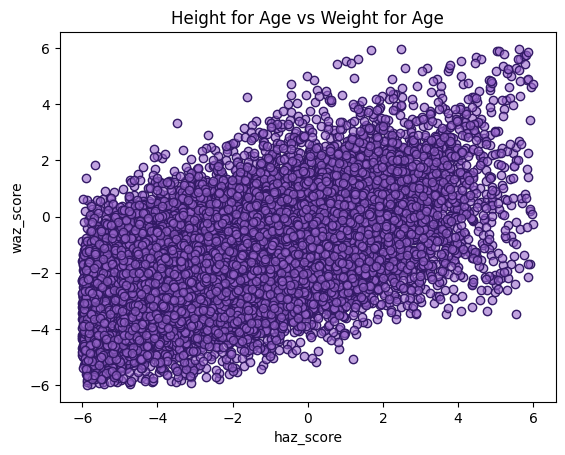

In [3]:
x = df['haz_score']
y = df['waz_score']

plt.scatter(x, y, color=color, edgecolor=edge_color)
plt.title('Height for Age vs Weight for Age')
plt.xlabel("haz_score")
plt.ylabel("waz_score")
# plt.savefig('screenshots/ss_bivariate/haz_waz_bivariate_scatter.png')
plt.show()

## Breastfeeding vs Weight-for-Age Z-Score

In [4]:
df['breastfeeding'].value_counts()
# note: Replace 9.0 with NaN before training model

breastfeeding
2.0    56273
1.0     4317
9.0      460
Name: count, dtype: int64

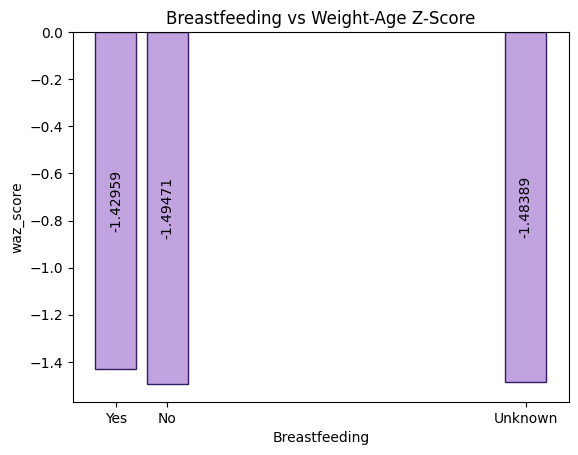

In [5]:
means = df.groupby('breastfeeding')['waz_score'].mean()

bars = plt.bar(means.index, means.values, color=color, edgecolor=edge_color)
plt.title('Breastfeeding vs Weight-Age Z-Score')
plt.xticks(means.index, ['Yes', 'No', 'Unknown'])
plt.xlabel("Breastfeeding")
plt.ylabel("waz_score")
plt.bar_label(bars, label_type='center', rotation=90)
# plt.savefig('screenshots/ss_bivariate/breastfeeding_waz_bivariate_bar.png')
plt.show()



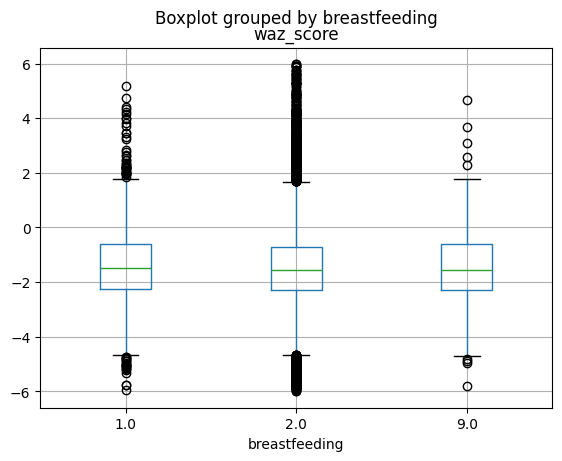

In [6]:
df.boxplot(column='waz_score', by='breastfeeding')
# plt.savefig('screenshots/ss_bivariate/breastfeeding_waz_bivariate_box.png')
plt.show()

## Mother's Educaiton vs Underweight

In [7]:
df['underweight'].value_counts()

underweight
0    43063
1    17987
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

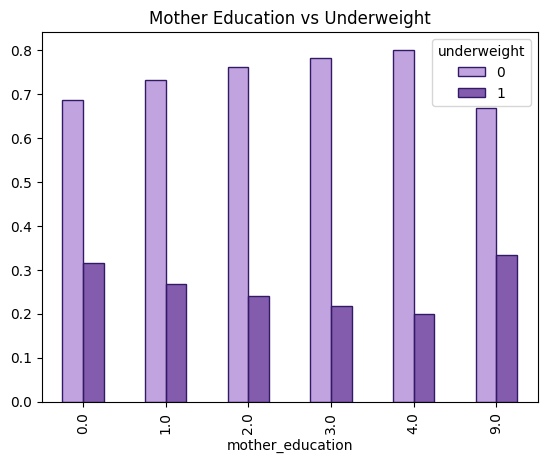

In [8]:
ct = pd.crosstab(df['mother_education'], df['underweight'], normalize='index')

dark_purple = (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/mother_education_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('Mother Education vs Underweight')
plt.show()

## urban_rural vs Underweight

In [9]:
df['urban_rural'].value_counts()

urban_rural
1    46768
0    14282
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

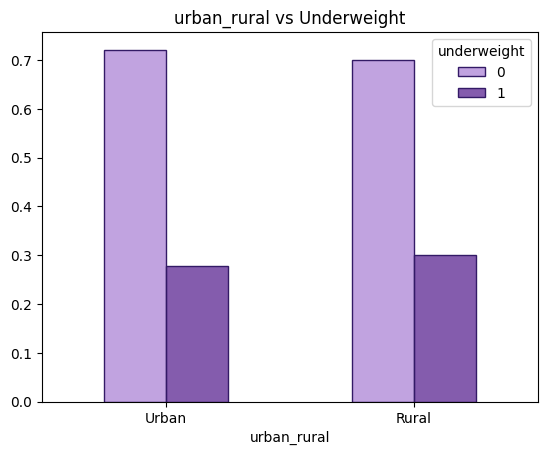

In [10]:
ct = pd.crosstab(df['urban_rural'], df['underweight'], normalize='index')

dark_purple =  (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/urban_rural_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('urban_rural vs Underweight')
plt.xticks([0, 1], ['Urban', 'Rural'], rotation=360)
plt.show()

## Wealth Index vs Underweight

In [11]:
df['wealth_index'].value_counts()

wealth_index
1.0    17577
2.0    14199
3.0    11547
4.0     9940
5.0     7787
Name: count, dtype: int64

1 - 5 -> poorest to richest

<Figure size 640x480 with 0 Axes>

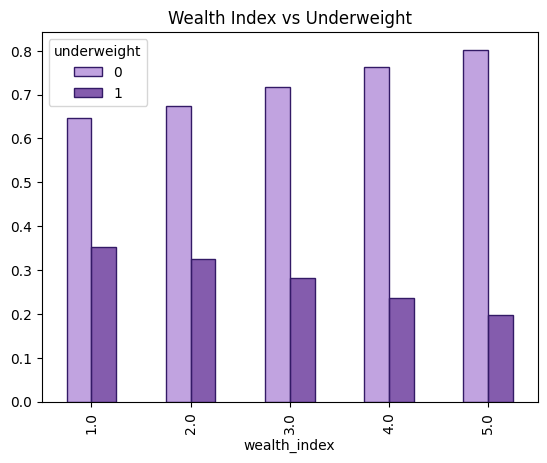

In [12]:
ct = pd.crosstab(df['wealth_index'], df['underweight'], normalize='index')

dark_purple =  (0.4, # redness
                0.2, # greenness
                0.6, # blueness
                0.8  # transparency
                )
plt.savefig('screenshots/ss_bivariate/wealth_undeweight_bivariate_grouped.png')
ct.plot(kind='bar', color=[color, dark_purple], edgecolor=edge_color)
plt.title('Wealth Index vs Underweight')
plt.show()

## Gender vs Stunted, Wasted, Underweight

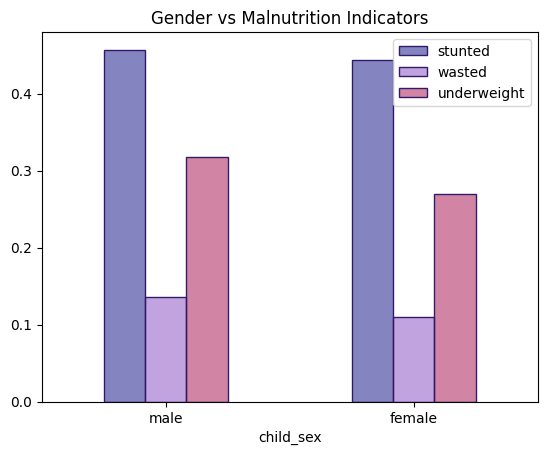

In [13]:
pinkish = (0.7, # redness
           0.2, # greenness
           0.4, # blueness
           0.6  # transparency
           )

bluish = (0.2, # redness
          0.2, # greenness
          0.6, # blueness
          0.6  # transparency
          )

df.groupby('child_sex')[['stunted', 'wasted', 'underweight']].mean().plot(kind='bar', color=[bluish, color, pinkish], edgecolor=edge_color)
plt.title('Gender vs Malnutrition Indicators')
plt.savefig('screenshots/ss_bivariate/gender_malnutrition_bivariate_grouped.png')
plt.xticks([0, 1], ['male', 'female'], rotation=360)
plt.show()

## `stunted` vs `waz_score`
Are stunted children also underweight?

In [14]:
df['stunted'].value_counts()

stunted
0    33527
1    27523
Name: count, dtype: int64

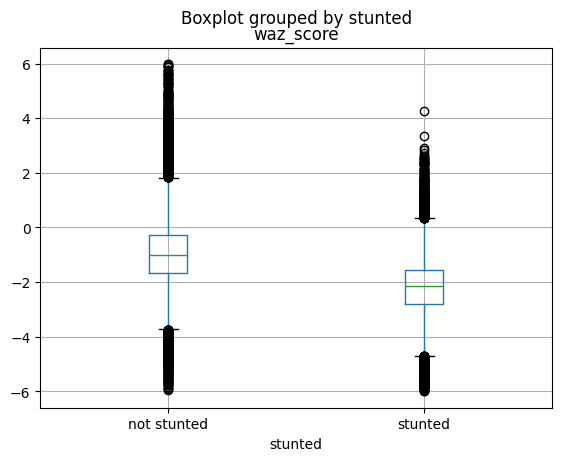

In [15]:
df.boxplot(column='waz_score', by='stunted')
plt.xticks([1, 2], ['not stunted', 'stunted'])
plt.savefig('screenshots/ss_bivariate/stunted_waz_bivariate_box.png')
plt.show()

## `waz_score` vs `underweight`

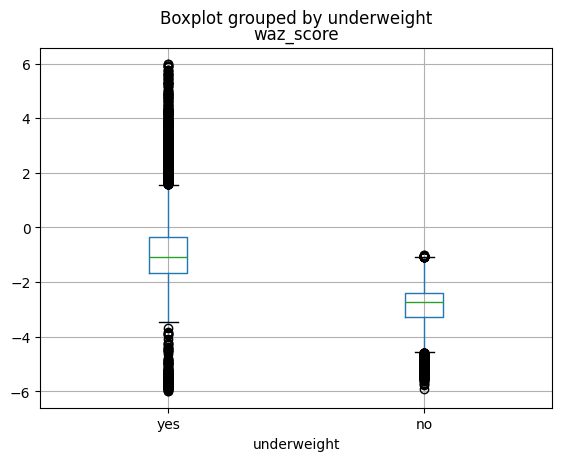

In [16]:
df.boxplot(column='waz_score', by='underweight')
plt.xticks([1, 2], ['yes', 'no'])
plt.savefig('screenshots/ss_bivariate/underweight_waz_bivariate_box.png')
plt.show()